# Cumulative NBS Loss Experiment

This notebook tests whether adding a cumulative Net Basin Supply (NBS) error term to the neural-network training objective improves cumulative forecast skill.

The current model workflow targets month-to-month NBS. USACE tests suggest that cumulative NBS forecasts may show systematic drift relative to observations. This notebook keeps the experiment narrow:

- use the existing feature/target construction workflow,
- train an NBS-only neural network,
- compare a monthly-only loss against cumulative-aware losses,
- evaluate monthly and cumulative skill.

This notebook is intended as an exploratory experiment, not a replacement for the operational forecast pipeline.

## 1. Imports and setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf

# Adjust this if needed. The notebook is assumed to live under notebooks/exploratory/.
sys.path.append(os.path.abspath('../../'))

from src.data_processor import CFSTransformer
from src.data_loader import DataLoader

## 2. User input

Update `local_path` if needed. This follows the style of the existing training notebook.

In [2]:
# Directory where the repo is cloned
local_path = '/Users/dannes/Documents/cnbs-predictor-dev/'

# Data directory
input_dir = local_path + 'cnbs-predictor/data/'

# Train/validation split
train_start_date = '1981-09-01'
train_end_date = '2005-12-01'

val_start_date = '2006-01-01'
val_end_date = '2010-03-01'

## 3. Reproducibility settings

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## 4. Load CFSR feature data

This mirrors the existing feature construction workflow: precipitation, evaporation, and air temperature are assembled into a basin/surface/component feature matrix.

In [4]:
# Read in CFSR basin-average data
pcp_data = pd.read_csv(input_dir + 'cfsr/CFSR_APCP_Basin_Avgs.csv')
evap_data = pd.read_csv(input_dir + 'cfsr/CFSR_EVAP_Basin_Avgs.csv')
tmp_data = pd.read_csv(input_dir + 'cfsr/CFSR_TMP_Basin_Avgs.csv')

# Date index
pcp_data['date'] = pd.to_datetime(pcp_data[['year', 'month']].assign(day=1))

X = pd.DataFrame({
    'superior_lake_precipitation':  pcp_data['sup_lake'],
    'michigan-huron_lake_precipitation': pcp_data['mih_lake'],
    'erie_lake_precipitation': pcp_data['eri_lake'],
    'ontario_lake_precipitation': pcp_data['ont_lake'],
    'superior_land_precipitation': pcp_data['sup_land'],
    'michigan-huron_land_precipitation': pcp_data['mih_land'],
    'erie_land_precipitation': pcp_data['eri_land'],
    'ontario_land_precipitation': pcp_data['ont_land'],
    'superior_lake_evaporation': evap_data['sup_lake'],
    'michigan-huron_lake_evaporation': evap_data['mih_lake'],
    'erie_lake_evaporation': evap_data['eri_lake'],
    'ontario_lake_evaporation': evap_data['ont_lake'],
    'superior_land_evaporation': evap_data['sup_land'],
    'michigan-huron_land_evaporation': evap_data['mih_land'],
    'erie_land_evaporation': evap_data['eri_land'],
    'ontario_land_evaporation': evap_data['ont_land'],
    'superior_lake_air_temperature': tmp_data['sup_lake'],
    'michigan-huron_lake_air_temperature': tmp_data['mih_lake'],
    'erie_lake_air_temperature': tmp_data['eri_lake'],
    'ontario_lake_air_temperature': tmp_data['ont_lake'],
    'superior_land_air_temperature': tmp_data['sup_land'],
    'michigan-huron_land_air_temperature': tmp_data['mih_land'],
    'erie_land_air_temperature': tmp_data['eri_land'],
    'ontario_land_air_temperature': tmp_data['ont_land'],
})

X.set_index(pd.to_datetime(pcp_data[['year', 'month']].assign(day=1)), inplace=True)

print(X.shape)
X.head()

(384, 24)


,superior_lake_precipitation,michigan-huron_lake_precipitation,erie_lake_precipitation,ontario_lake_precipitation,superior_land_precipitation,michigan-huron_land_precipitation,erie_land_precipitation,ontario_land_precipitation,superior_lake_evaporation,michigan-huron_lake_evaporation,...,erie_land_evaporation,ontario_land_evaporation,superior_lake_air_temperature,michigan-huron_lake_air_temperature,erie_lake_air_temperature,ontario_lake_air_temperature,superior_land_air_temperature,michigan-huron_land_air_temperature,erie_land_air_temperature,ontario_land_air_temperature
1979-01-01,65.888903,98.979232,111.084728,185.093368,47.508515,90.515367,99.399974,161.137828,106.811695,79.297714,...,23.048358,28.464477,262.255341,265.433197,267.722443,268.185791,255.093093,261.532308,265.363916,265.067010
1979-02-01,72.947135,55.946494,63.410142,70.122365,62.053984,46.708860,65.615548,72.420295,54.096258,59.229013,...,20.770884,22.337271,261.875214,264.288635,265.308228,263.483124,255.898093,259.626467,263.266410,259.939060
1979-03-01,140.381977,124.561790,112.519854,88.029649,137.960518,139.176012,114.395377,90.420876,31.075613,18.882359,...,39.507209,41.663776,268.603607,271.353882,272.955719,274.455627,266.163366,270.552521,274.126952,273.725244
1979-04-01,82.937371,127.197408,166.097458,149.837977,85.055879,120.155565,152.609512,137.052291,12.489237,9.028745,...,57.952056,68.308031,272.341217,274.958191,276.353729,277.062256,271.525285,275.165788,277.484784,277.451298
1979-05-01,119.764162,96.168734,129.445753,96.733309,118.678327,110.213354,129.130588,109.789858,-4.519337,-4.817537,...,110.571305,105.531544,276.595825,279.611176,281.265320,282.966248,278.743035,282.106158,284.762079,284.633596


## 5. Build forecast-like feature matrix

Features are shifted to create lead-time inputs, then month indicators and GLSEA SST are merged in.

In [5]:
# Shift features to create lead times from 0 to 9 months
X_shifted = CFSTransformer(X).shift_variables(lag=0, lead=10)

# Add calendar month indicators
X_shifted = pd.concat(
    [X_shifted, pd.DataFrame({'month': X_shifted.index.month}, index=X_shifted.index)],
    axis=1,
)
X_shifted = pd.get_dummies(X_shifted, columns=['month'], prefix='month')

feature_column_order = (
    [f'month_{i}' for i in range(1, 13)] +
    [
        f'{lake}_{surface_type}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for surface_type in ['lake', 'land']
        for comp in ['precipitation', 'evaporation', 'air_temperature']
        for m in range(10)
    ]
)

X_reorg = X_shifted.reindex(columns=feature_column_order)

# Load GLSEA SST and merge with shifted features
dataloader = DataLoader()
df_sst_k = dataloader.glsea(input_dir + 'glsea/oisst_sst_1981-2024.csv', units='K')
X_merged = pd.merge(df_sst_k, X_reorg, left_index=True, right_index=True, how='inner')

print(X_merged.shape)
X_merged.head()

(343, 256)


,superior_sst,michigan-huron_sst,erie_sst,ontario_sst,month_1,month_2,month_3,month_4,month_5,month_6,...,ontario_land_air_temperature_mo0,ontario_land_air_temperature_mo1,ontario_land_air_temperature_mo2,ontario_land_air_temperature_mo3,ontario_land_air_temperature_mo4,ontario_land_air_temperature_mo5,ontario_land_air_temperature_mo6,ontario_land_air_temperature_mo7,ontario_land_air_temperature_mo8,ontario_land_air_temperature_mo9
date,,,,,,,,,,,,,,,,,,,,,
1981-09-01,289.16,292.925,295.60,293.36,False,False,False,False,False,False,...,286.578745,279.378374,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814
1981-10-01,280.79,285.910,289.04,286.56,False,False,False,False,False,False,...,279.378374,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232
1981-11-01,279.02,281.815,284.75,283.00,False,False,False,False,False,False,...,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434
1981-12-01,278.01,279.230,280.41,279.62,False,False,False,False,False,False,...,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434,287.470924
1982-01-01,276.40,276.885,275.64,275.59,True,False,False,False,False,False,...,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434,287.470924,282.101856


## 6. Load and construct target data

This notebook focuses only on NBS targets. The existing workflow constructs all targets, then we subset to NBS-only columns after lead shifting.

In [6]:
# Load target datasets
l2 = dataloader.l2swbm(input_dir + 'l2swbm/')
glcc = dataloader.glcc(input_dir + 'glcc/', units='mm')

targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evaporation_obs'],
    'superior_target_precipitation': l2['superior_precipitation_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evaporation_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precipitation_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evaporation_obs'],
    'erie_target_precipitation': l2['erie_precipitation_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evaporation_obs'],
    'ontario_target_precipitation': l2['ontario_precipitation_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs'],
}).dropna()

print(targets.shape)
targets.head()

(876, 16)


,superior_target_evaporation,superior_target_precipitation,superior_target_runoff,superior_target_nbs,michigan-huron_target_evaporation,michigan-huron_target_precipitation,michigan-huron_target_runoff,michigan-huron_target_nbs,erie_target_evaporation,erie_target_precipitation,erie_target_runoff,erie_target_nbs,ontario_target_evaporation,ontario_target_precipitation,ontario_target_runoff,ontario_target_nbs
date,,,,,,,,,,,,,,,,
1950-01-01,125.357918,88.75,33.2,14.026862,95.709892,91.03,104.7,94.677343,38.810083,166.0,238.3,550.186890,75.883804,111.8,271.8,375.028505
1950-02-01,70.413371,36.98,25.5,-8.961299,59.667369,64.88,65.8,57.923217,40.703714,94.8,136.2,258.878682,77.272852,88.8,147.1,188.013699
1950-03-01,42.505142,62.08,31.0,49.607194,36.461632,77.05,81.9,124.142145,26.439582,97.0,162.6,427.763105,43.856645,71.4,196.6,323.419078
1950-04-01,25.310708,89.29,48.1,142.365472,23.005784,84.70,125.2,200.438931,16.345690,101.3,161.4,367.968263,17.753245,60.1,283.2,529.412835
1950-05-01,-8.965747,147.60,115.5,340.750102,0.003105,55.79,110.9,130.425081,10.834650,47.3,68.1,115.222385,2.194818,52.9,117.2,182.353310


## 7. Shift targets and select NBS-only lead targets

The cumulative loss is easiest to interpret if the neural network only predicts NBS lead columns. This avoids accidental cumulative sums across unrelated components.

In [7]:
# Shift all targets to lead format
targets_lead = CFSTransformer(targets).shift_variables(lag=0, lead=12)

# Keep NBS only, ordered by lake then lead
nbs_column_order = [
    f'{lake}_target_nbs_mo{m}'
    for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
    for m in range(12)
]

y_nbs = targets_lead.reindex(columns=nbs_column_order)

# Align features and NBS targets
aligned_X, aligned_y = X_merged.align(y_nbs, join='inner', axis=0)

print(f'Number of features: {aligned_X.shape[1]}')
print(f'Number of NBS targets: {aligned_y.shape[1]}')
aligned_y.head()

Number of features: 256
Number of NBS targets: 48


,superior_target_nbs_mo0,superior_target_nbs_mo1,superior_target_nbs_mo2,superior_target_nbs_mo3,superior_target_nbs_mo4,superior_target_nbs_mo5,superior_target_nbs_mo6,superior_target_nbs_mo7,superior_target_nbs_mo8,superior_target_nbs_mo9,...,ontario_target_nbs_mo2,ontario_target_nbs_mo3,ontario_target_nbs_mo4,ontario_target_nbs_mo5,ontario_target_nbs_mo6,ontario_target_nbs_mo7,ontario_target_nbs_mo8,ontario_target_nbs_mo9,ontario_target_nbs_mo10,ontario_target_nbs_mo11
date,,,,,,,,,,,,,,,,,,,,,
1981-09-01,-10.263557,34.211858,-12.250052,-19.500759,-32.501265,-15.141506,42.080585,156.602019,212.455636,83.101706,...,234.739653,122.142311,103.218855,77.691611,359.545677,447.836643,211.598652,288.013901,72.253198,32.685971
1981-10-01,34.211858,-12.250052,-19.500759,-32.501265,-15.141506,42.080585,156.602019,212.455636,83.101706,204.244790,...,122.142311,103.218855,77.691611,359.545677,447.836643,211.598652,288.013901,72.253198,32.685971,74.916911
1981-11-01,-12.250052,-19.500759,-32.501265,-15.141506,42.080585,156.602019,212.455636,83.101706,204.244790,97.845913,...,103.218855,77.691611,359.545677,447.836643,211.598652,288.013901,72.253198,32.685971,74.916911,6.881257
1981-12-01,-19.500759,-32.501265,-15.141506,42.080585,156.602019,212.455636,83.101706,204.244790,97.845913,96.345006,...,77.691611,359.545677,447.836643,211.598652,288.013901,72.253198,32.685971,74.916911,6.881257,213.096990
1982-01-01,-32.501265,-15.141506,42.080585,156.602019,212.455636,83.101706,204.244790,97.845913,96.345006,164.216917,...,359.545677,447.836643,211.598652,288.013901,72.253198,32.685971,74.916911,6.881257,213.096990,242.564308


## 8. Train/test split and scaling

The split is chronological, matching the existing training notebook. Scaling is fit on the training period only.

In [8]:
X_train = aligned_X.loc[train_start_date:train_end_date]
y_train = aligned_y.loc[train_start_date:train_end_date]

X_test = aligned_X.loc[val_start_date:val_end_date]
y_test = aligned_y.loc[val_start_date:val_end_date]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print(X_train_scaled.shape, y_train_scaled.shape)
print(X_test_scaled.shape, y_test_scaled.shape)

(292, 256) (292, 48)
(51, 256) (51, 48)


## 9. Loss functions

The baseline loss is ordinary monthly MSE. The cumulative-aware loss adds an error term on cumulative NBS over the 12-month forecast horizon.

Because targets are ordered as:

```text
lake_1_mo0 ... lake_1_mo11, lake_2_mo0 ... lake_2_mo11, ...
```

we reshape the output into:

```text
samples × lakes × leads
```

before applying `cumsum` along the lead axis.

In [9]:
N_LAKES = 4
N_LEADS = 12


def monthly_mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))


def cumulative_nbs_loss(alpha=1.0, beta=0.5):
    """
    Combined monthly and cumulative NBS loss.

    Parameters
    ----------
    alpha : float
        Weight on monthly MSE.
    beta : float
        Weight on cumulative MSE along the lead-time axis.
    """
    def loss(y_true, y_pred):
        monthly_mse = tf.reduce_mean(tf.square(y_true - y_pred))

        y_true_reshaped = tf.reshape(y_true, (-1, N_LAKES, N_LEADS))
        y_pred_reshaped = tf.reshape(y_pred, (-1, N_LAKES, N_LEADS))

        y_true_cum = tf.cumsum(y_true_reshaped, axis=2)
        y_pred_cum = tf.cumsum(y_pred_reshaped, axis=2)

        cumulative_mse = tf.reduce_mean(tf.square(y_true_cum - y_pred_cum))

        return alpha * monthly_mse + beta * cumulative_mse

    return loss

## 10. Model builder

Keep the architecture simple and fixed across experiments so the loss function is the main experimental variable.

In [10]:
def build_nbs_nn(input_dim, output_dim, random_seed=RANDOM_SEED):
    tf.keras.utils.set_random_seed(random_seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(output_dim),
    ])
    return model

## 11. Evaluation utilities

Metrics are reported both for month-to-month NBS and cumulative NBS. The cumulative metrics compare cumulative sums along the forecast lead axis for each lake.

In [11]:
def unscale_to_df(y_scaled, scaler, index, columns):
    return pd.DataFrame(
        scaler.inverse_transform(y_scaled),
        index=index,
        columns=columns,
    )


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def reshape_nbs_values(df):
    """Return values as samples × lakes × leads."""
    return df.to_numpy().reshape(len(df), N_LAKES, N_LEADS)


def cumulative_df(df):
    """Return a DataFrame with cumulative NBS along the lead axis."""
    arr = reshape_nbs_values(df)
    cum = np.cumsum(arr, axis=2).reshape(len(df), N_LAKES * N_LEADS)
    return pd.DataFrame(cum, index=df.index, columns=df.columns)


def evaluate_nbs_predictions(model_name, y_true_df, y_pred_df):
    monthly_true = y_true_df.to_numpy().ravel()
    monthly_pred = y_pred_df.to_numpy().ravel()

    y_true_cum = cumulative_df(y_true_df)
    y_pred_cum = cumulative_df(y_pred_df)

    cumulative_true = y_true_cum.to_numpy().ravel()
    cumulative_pred = y_pred_cum.to_numpy().ravel()

    return {
        'Model': model_name,
        'Monthly_RMSE': rmse(monthly_true, monthly_pred),
        'Monthly_R2': r2_score(monthly_true, monthly_pred),
        'Monthly_Bias': np.mean(monthly_pred - monthly_true),
        'Cumulative_RMSE': rmse(cumulative_true, cumulative_pred),
        'Cumulative_R2': r2_score(cumulative_true, cumulative_pred),
        'Cumulative_Bias': np.mean(cumulative_pred - cumulative_true),
    }


def integrated_nbs_metrics(y_true_df, y_pred_df, windows=(1, 3, 6)):
    rows = []
    true_arr = reshape_nbs_values(y_true_df)
    pred_arr = reshape_nbs_values(y_pred_df)

    lake_names = ['superior', 'michigan-huron', 'erie', 'ontario']

    for lake_idx, lake in enumerate(lake_names):
        for window in windows:
            true_integrated = []
            pred_integrated = []

            for start in range(N_LEADS - window + 1):
                true_integrated.append(true_arr[:, lake_idx, start:start + window].sum(axis=1))
                pred_integrated.append(pred_arr[:, lake_idx, start:start + window].sum(axis=1))

            yt = np.concatenate(true_integrated)
            yp = np.concatenate(pred_integrated)

            rows.append({
                'Lake': lake,
                'Window': window,
                'RMSE': rmse(yt, yp),
                'R2': r2_score(yt, yp),
                'Bias': np.mean(yp - yt),
            })

    return pd.DataFrame(rows)

## 12. Training function

In [12]:
def train_one_experiment(
    label,
    loss_fn,
    epochs=100,
    batch_size=32,
    patience=15,
):
    model = build_nbs_nn(
        input_dim=X_train_scaled.shape[1],
        output_dim=y_train_scaled.shape[1],
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss_fn,
        metrics=['mae'],
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stopping],
    )

    y_pred_scaled = model.predict(X_test_scaled, verbose=0)

    y_true_df = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
    y_pred_df = unscale_to_df(y_pred_scaled, y_scaler, y_test.index, y_test.columns)

    metrics = evaluate_nbs_predictions(label, y_true_df, y_pred_df)
    integrated = integrated_nbs_metrics(y_true_df, y_pred_df)

    return {
        'label': label,
        'model': model,
        'history': history,
        'y_pred_scaled': y_pred_scaled,
        'y_true_df': y_true_df,
        'y_pred_df': y_pred_df,
        'metrics': metrics,
        'integrated': integrated,
    }

## 13. Run experiments

Start with a small grid of cumulative-loss weights. `beta = 0` is the baseline monthly-only loss.

In [13]:
experiments = [
    ('monthly_only_beta_0', cumulative_nbs_loss(alpha=1.0, beta=0.0)),
    ('cumulative_beta_0_1', cumulative_nbs_loss(alpha=1.0, beta=0.1)),
    ('cumulative_beta_0_5', cumulative_nbs_loss(alpha=1.0, beta=0.5)),
    ('cumulative_beta_1_0', cumulative_nbs_loss(alpha=1.0, beta=1.0)),
]

results = {}

for label, loss_fn in experiments:
    print(f'Running {label}...')
    results[label] = train_one_experiment(label, loss_fn)

print('Done')

Running monthly_only_beta_0...
Running cumulative_beta_0_1...
Running cumulative_beta_0_5...
Running cumulative_beta_1_0...
Done


## 14. Compare headline metrics

In [14]:
summary = pd.DataFrame([res['metrics'] for res in results.values()])
summary = summary.sort_values('Cumulative_RMSE').reset_index(drop=True)
summary

,Model,Monthly_RMSE,Monthly_R2,Monthly_Bias,Cumulative_RMSE,Cumulative_R2,Cumulative_Bias
0,cumulative_beta_0_5,80.475642,0.633884,1.256386,189.042938,0.918261,17.437314
1,cumulative_beta_1_0,82.756166,0.612840,-2.421265,191.300643,0.916297,-17.264038
2,cumulative_beta_0_1,76.426739,0.669797,-1.599560,191.575729,0.916056,-4.144288
3,monthly_only_beta_0,73.546904,0.694213,1.660341,204.262848,0.904570,21.439756


Result: Cumulative RMSE improves across all beta values. That is an early indication that we can control for the drift in cumulative NBS using this multi-objective optimization approach.

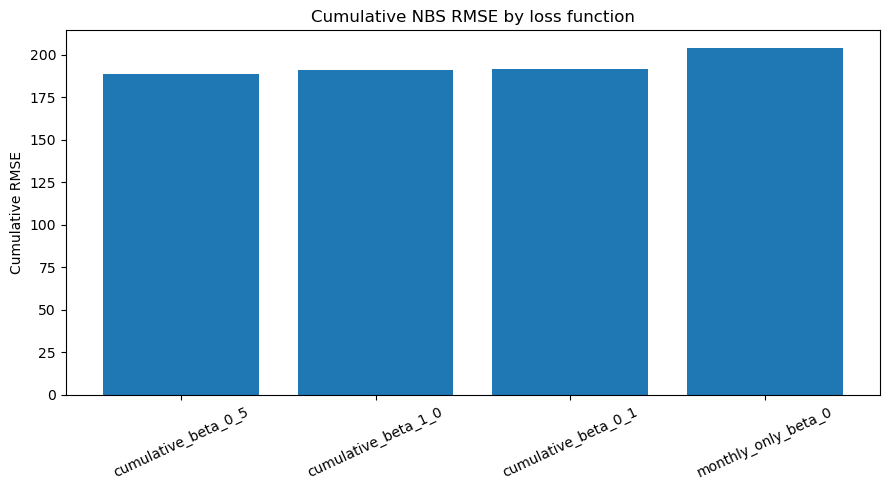

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(summary['Model'], summary['Cumulative_RMSE'])
ax.set_ylabel('Cumulative RMSE')
ax.set_title('Cumulative NBS RMSE by loss function')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

Result: The 0.5 value of beta seems to do well (actually the best for cumulative NBS RMSE)

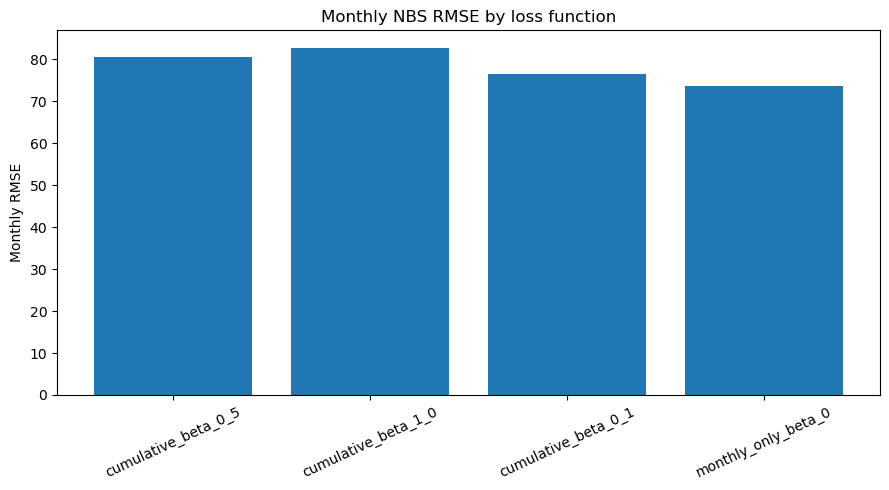

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(summary['Model'], summary['Monthly_RMSE'])
ax.set_ylabel('Monthly RMSE')
ax.set_title('Monthly NBS RMSE by loss function')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 15. Integrated NBS metrics by lake and window

This mirrors the USACE-relevant framing: how well does the model do for 1-, 3-, and 6-month integrated NBS?

In [21]:
integrated_all = pd.concat(
    [
        res['integrated'].assign(Model=label)
        for label, res in results.items()
    ],
    ignore_index=True,
)

integrated_all

,Lake,Window,RMSE,R2,Bias,Model
0,superior,1,46.402896,0.602840,15.215669,monthly_only_beta_0
1,superior,3,87.506620,0.749206,47.760819,monthly_only_beta_0
2,superior,6,144.656754,0.665595,99.492894,monthly_only_beta_0
3,michigan-huron,1,42.208148,0.637877,3.723938,monthly_only_beta_0
4,michigan-huron,3,74.348709,0.798081,9.665586,monthly_only_beta_0
5,michigan-huron,6,95.479424,0.835692,19.015790,monthly_only_beta_0
6,erie,1,101.054230,0.622198,-3.208110,monthly_only_beta_0
7,erie,3,174.096890,0.797367,-11.096609,monthly_only_beta_0
8,erie,6,247.912645,0.806238,-27.378528,monthly_only_beta_0
9,ontario,1,86.544061,0.624329,-9.090135,monthly_only_beta_0


Adding a cumulative loss term improves overall cumulative performance, but the optimal weighting reflects a tradeoff between lakes with opposing bias structures. A single global weighting improves aggregate performance but does not fully resolve lake-specific biases.

In [18]:
integrated_summary = (
    integrated_all
    .groupby(['Model', 'Window'])[['RMSE', 'R2', 'Bias']]
    .mean()
    .reset_index()
    .sort_values(['Window', 'RMSE'])
)

integrated_summary

,Model,Window,RMSE,R2,Bias
9,monthly_only_beta_0,1,69.052334,0.621811,1.660341
0,cumulative_beta_0_1,1,71.558439,0.596874,-1.599560
3,cumulative_beta_0_5,1,75.155223,0.558328,1.256386
6,cumulative_beta_1_0,1,77.480361,0.527636,-2.421265
10,monthly_only_beta_0,3,122.630922,0.783215,5.602420
1,cumulative_beta_0_1,3,122.840565,0.786884,-5.605450
4,cumulative_beta_0_5,3,124.748174,0.779047,3.789446
7,cumulative_beta_1_0,3,126.735017,0.770029,-8.372017
5,cumulative_beta_0_5,6,170.415056,0.798880,6.783560
2,cumulative_beta_0_1,6,171.049471,0.801161,-15.176049


Adding cumulative loss improves long-horizon consistency while preserving most short-term skill, with β ≈ 0.5 providing the best balance. (Results vary between lakes!!!)

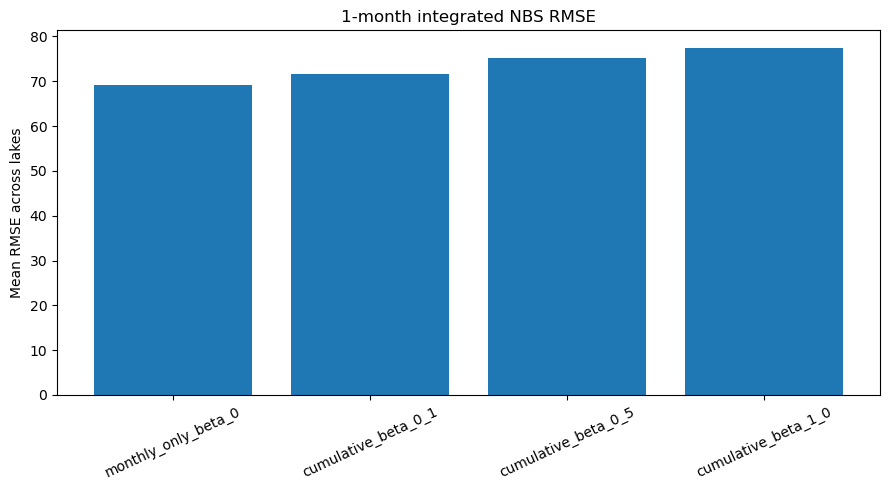

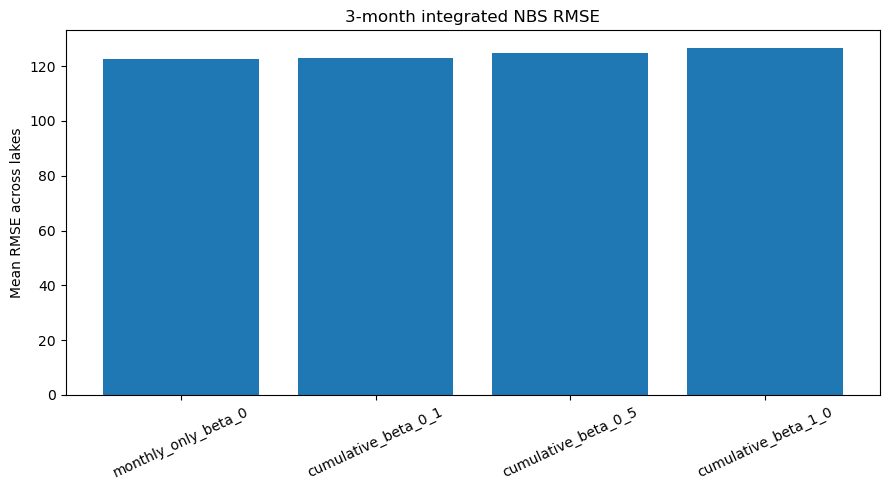

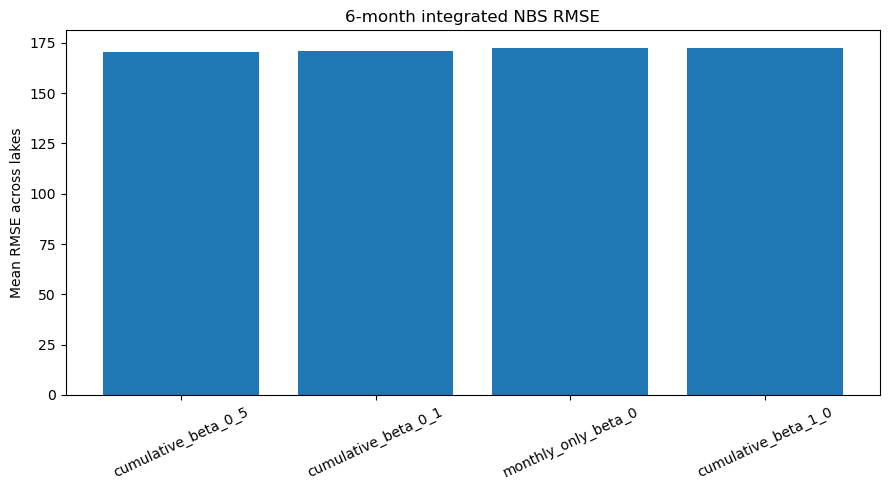

In [19]:
for window in sorted(integrated_summary['Window'].unique()):
    subset = integrated_summary[integrated_summary['Window'] == window]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(subset['Model'], subset['RMSE'])
    ax.set_ylabel('Mean RMSE across lakes')
    ax.set_title(f'{window}-month integrated NBS RMSE')
    ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

## 16. Plot cumulative forecasts for a selected lake

This diagnostic helps show whether the cumulative-aware objective reduces drift visually.

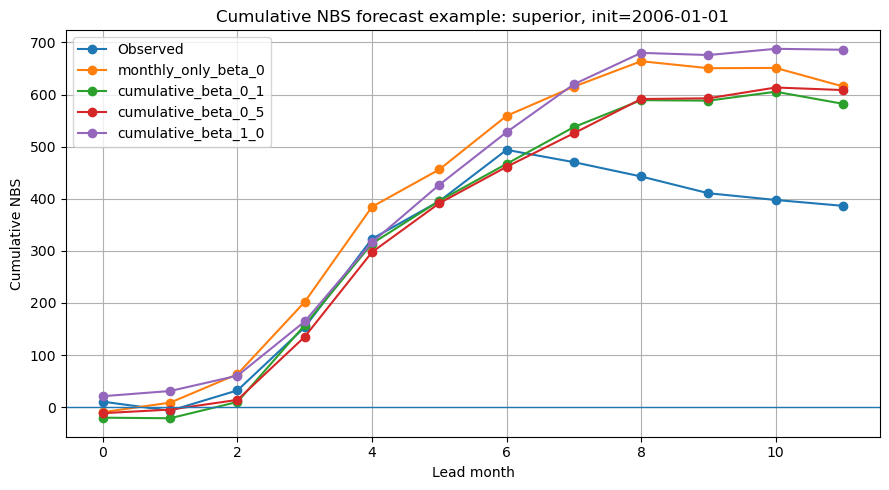

In [20]:
def get_lake_cols(lake):
    return [f'{lake}_target_nbs_mo{m}' for m in range(N_LEADS)]


def plot_cumulative_forecast_example(results, init_date=None, lake='superior'):
    if init_date is None:
        init_date = y_test.index[0]

    cols = get_lake_cols(lake)
    leads = np.arange(N_LEADS)

    fig, ax = plt.subplots(figsize=(9, 5))

    # True cumulative values
    first_result = next(iter(results.values()))
    y_true = first_result['y_true_df'].loc[init_date, cols].to_numpy()
    ax.plot(leads, np.cumsum(y_true), marker='o', label='Observed')

    for label, res in results.items():
        y_pred = res['y_pred_df'].loc[init_date, cols].to_numpy()
        ax.plot(leads, np.cumsum(y_pred), marker='o', label=label)

    ax.axhline(0, linewidth=1)
    ax.set_xlabel('Lead month')
    ax.set_ylabel('Cumulative NBS')
    ax.set_title(f'Cumulative NBS forecast example: {lake}, init={init_date.date()}')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_cumulative_forecast_example(results, lake='superior')

The observed and predicted diverge after six months, since that's not included in the loss function. **This is expected and is a strong signal that including the cumulative NBS as part of the loss function is helping to anchor our results**

## Results summary for the neural network model

These results suggest that the primary limitation of the baseline model is not its ability to capture monthly variability, but its lack of constraint on accumulated behavior. Incorporating cumulative loss acts as a regularizer on long-term drift. It does seem to help!